# Nonlinear Least Squares Benchmark Analysis

In [7]:
from experiments import *
from visualization import *

import inspect
from optimization_project import problems as problems_module

In [8]:
problems = [
    cls() for name, cls in inspect.getmembers(problems_module, inspect.isclass)
    if name.endswith("Problem") and name != "Problem"
]

In [9]:
problems_misra1A = problems.pop(6)

## Overall Results

In [10]:
df_results = benchmark_methods(problems)

Running problem: BoxBOD
Running problem: Chwirut1


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))


Running problem: DanWood
Running problem: Eckerle4
Running problem: Lanczos3
Running problem: MGH17


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])


Running problem: Roszman1
Running problem: Thurber


In [11]:
df_results

,problem,difficulty,classification_model,structure,method,start_name,success,iterations,final_rss,parameter_error,relative_parameter_error,rss_error,relative_rss_error,gradient_norm
0,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,26,1.168009e+03,1.762844e-07,8.244907e-10,4.444701e-08,3.805365e-11,1.199891e-04
1,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 1,True,24,1.168009e+03,9.859595e-04,4.611379e-06,2.701489e-06,2.312901e-09,2.401449e-01
2,BoxBOD,Higher,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,12,1.168009e+03,1.230070e-07,5.753095e-10,4.444723e-08,3.805385e-11,1.417062e-05
3,BoxBOD,Higher,Exponential,Overdetermined,LM-lm,NIST Start 2,True,8,1.168009e+03,1.660473e-03,7.766111e-06,7.757208e-06,6.641395e-09,4.053286e-01
4,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 1,True,20,2.384477e+03,5.213287e-09,2.734222e-08,9.350515e-09,3.921411e-12,6.339257e-03
5,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 1,True,11,2.384477e+03,3.072196e-06,1.611280e-05,4.255426e-07,1.784637e-10,5.402049e+00
6,Chwirut1,Lower,Exponential,Overdetermined,ModifiedGN,NIST Start 2,True,15,2.384477e+03,4.752047e-08,2.492315e-07,9.415544e-09,3.948683e-12,4.543440e-02
7,Chwirut1,Lower,Exponential,Overdetermined,LM-lm,NIST Start 2,True,5,2.384477e+03,2.353497e-06,1.234343e-05,7.749459e-07,3.249961e-10,9.618043e+00
8,DanWood,Lower,Miscellaneous,Overdetermined,ModifiedGN,NIST Start 1,True,10,4.317308e-03,2.542973e-09,6.460434e-10,8.984133e-15,2.080957e-12,9.295623e-10
9,DanWood,Lower,Miscellaneous,Overdetermined,LM-lm,NIST Start 1,True,6,4.317308e-03,2.480603e-08,6.301983e-09,8.687495e-15,2.012248e-12,9.487881e-09


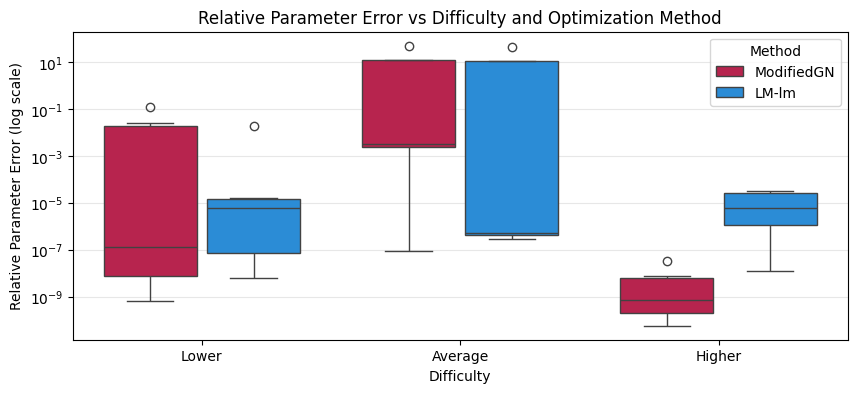

In [12]:
plot_boxplot(df_results, x="difficulty", y="relative_parameter_error",
             xlabel="Difficulty", ylabel="Relative Parameter Error",
             order=difficulty_order, palette=method_palette)

---

In [13]:
problems_2d = [p for p in problems if p.n == 2]

C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in exp
  return b[0] * (1 - np.exp(-b[1] * x))
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_higher.py:187: RuntimeWarning: overflow encountered in multiply
  return b[0] * (1 - np.exp(-b[1] * x))
c:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\notebooks\visualization.py:116: RuntimeWarning: overflow encountered in square
  Z[i, j] = np.sum(problem.F(p)**2)


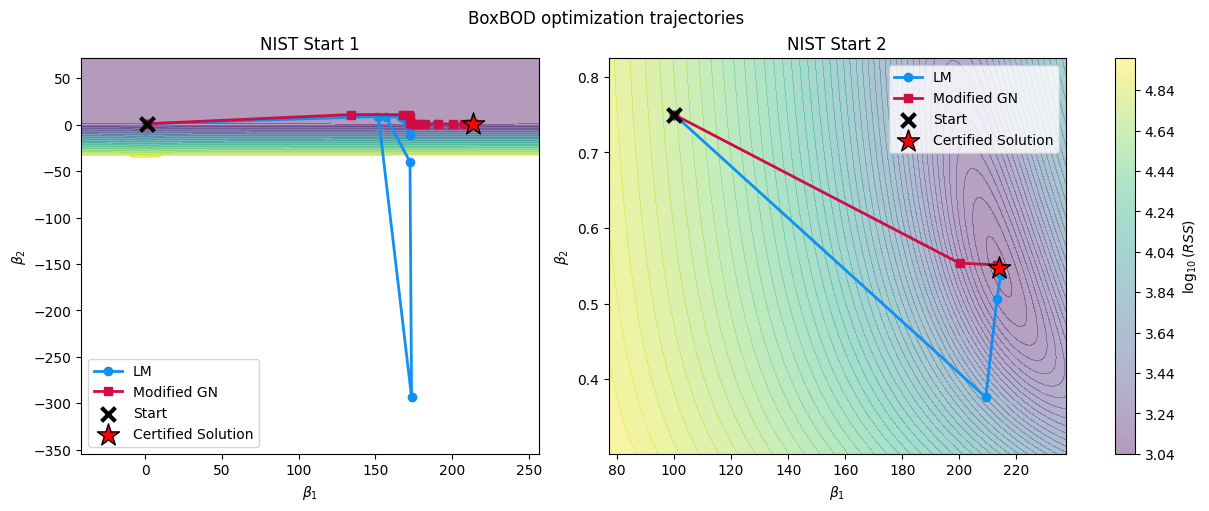

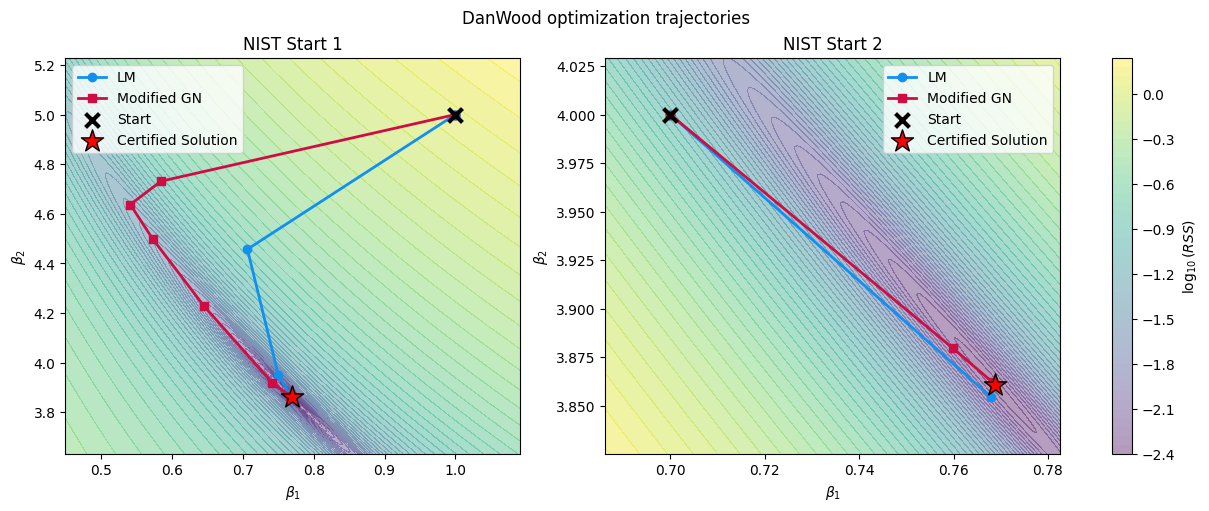

In [14]:
trajectory_data = generate_trajectory_data(
    problems_2d
)

for problem_data in trajectory_data:

    plot_optimizer_paths(problem_data)

---

In [15]:
def compare_methods_convergence(problems):

    for problem in problems:

        starts = problem.get_starting_points()
        n_starts = len(starts)

        print(f"\n=== {problem.name} ===")

        fig, axes = plt.subplots(1, n_starts, figsize=(6 * n_starts, 5), constrained_layout=True)

        if n_starts == 1:
            axes = [axes]

        for ax, (name, x0) in zip(axes, starts.items()):

            # ---------------------------------------------------
            # 1. Modified GN (Secular)
            # ---------------------------------------------------

            result_mgn = modified_gauss_newton(problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="secular"
            )

            # TO BE DELETED
            # ---------------------------------------------------
            # 2. Modified GN (Bisection)
            # ---------------------------------------------------

            result_bis = modified_gauss_newton(
                problem,
                x0,
                M0=1e-3,
                L0=1e-6,
                tol=1e-6,
                max_iter=100,
                subproblem_method="bisection"
            )

            # ---------------------------------------------------
            # 3. SciPy LM (history safe extraction)
            # ---------------------------------------------------

            lm_res = run_lm_with_history(problem, x0)
            hist_sp = [
                np.sum(problem.F(x) ** 2)
                for x in lm_res.x_history
            ]


            ax.semilogy(result_mgn.rss_history, label="Modified GN (Secular)", linewidth=2,
                        color=method_palette["ModifiedGN"])

            ax.semilogy(result_bis.rss_history, label="Modified GN (Bisection)", linestyle="--",
                        color="black", alpha=0.7)

            ax.semilogy(hist_sp, label="SciPy LM", linewidth=2, 
                        color=method_palette["LM-lm"], alpha=0.9)

            ax.set_title(name)
            ax.set_xlabel("Iteration")
            ax.set_ylabel("RSS")
            ax.grid(True, which="both", ls="-", alpha=0.4)
            ax.legend()

        fig.suptitle(
            f"{problem.name} – convergence comparison",
            fontsize=14
        )

        plt.tight_layout()
        plt.show()


=== BoxBOD ===


C:\Users\olenk\AppData\Local\Temp\ipykernel_76340\1546752592.py:51: RuntimeWarning: overflow encountered in square
  np.sum(problem.F(x) ** 2)
C:\Users\olenk\AppData\Local\Temp\ipykernel_76340\1546752592.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


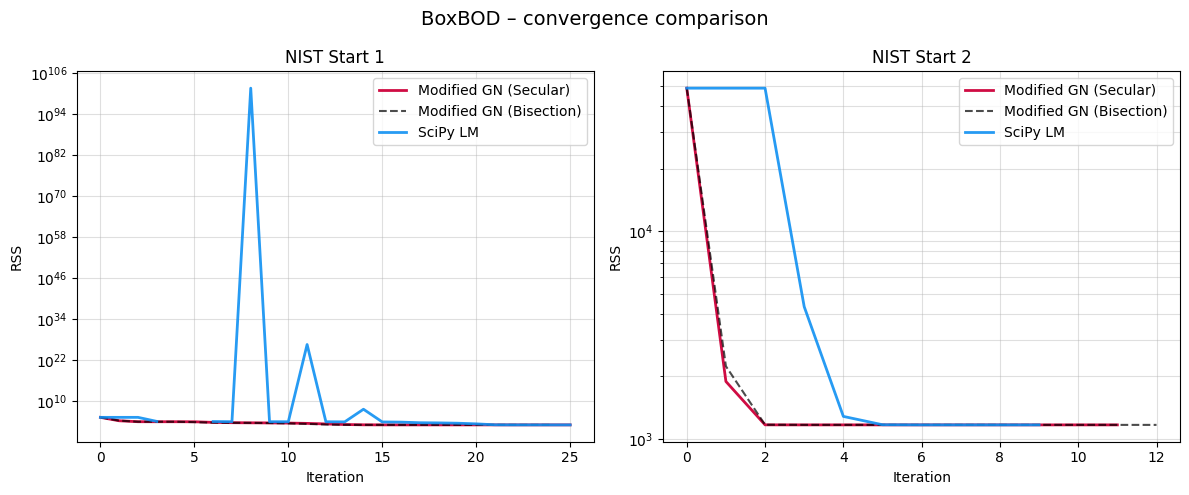


=== Chwirut1 ===


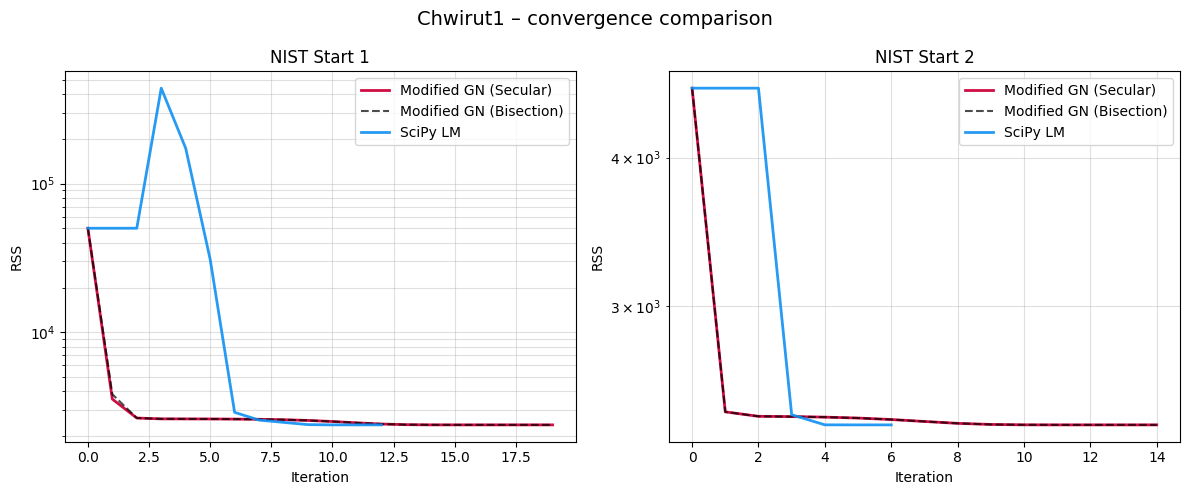


=== DanWood ===


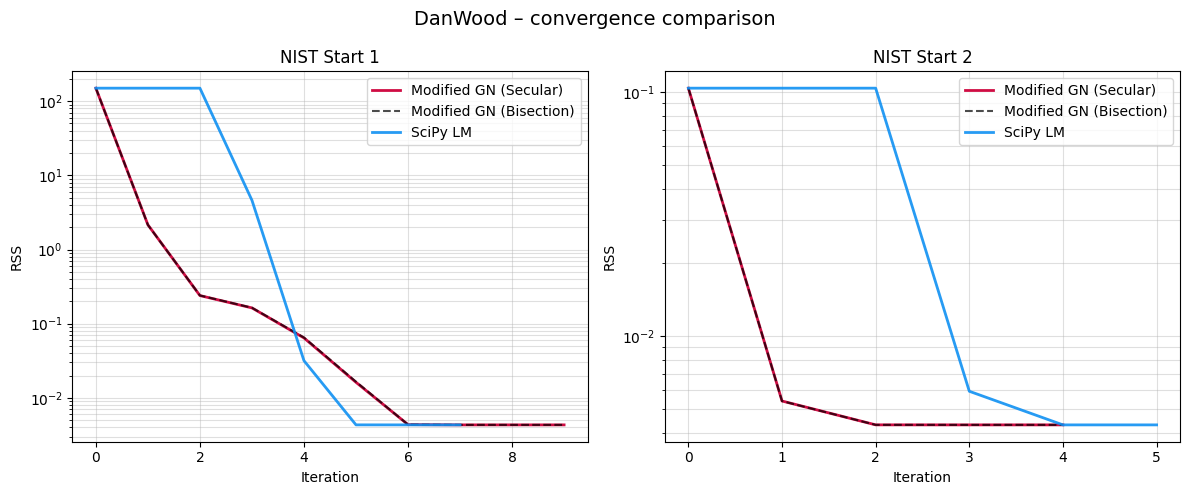


=== Eckerle4 ===


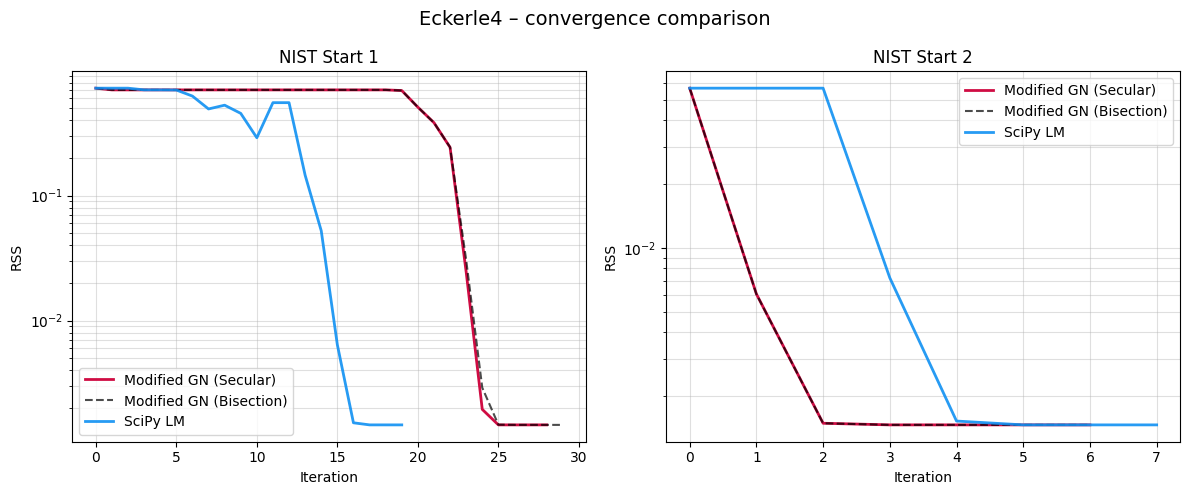


=== Lanczos3 ===


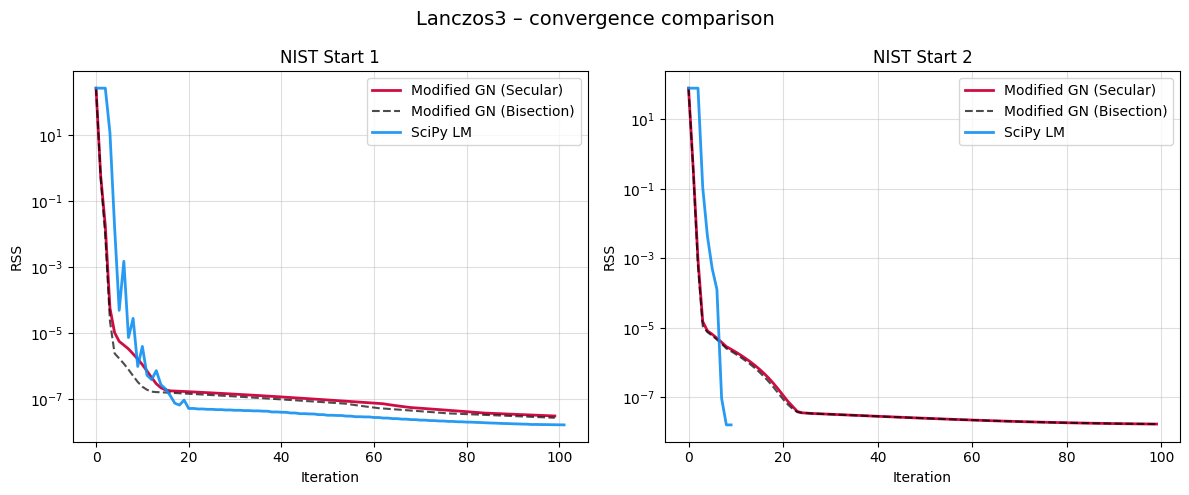


=== MGH17 ===


C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:44: RuntimeWarning: overflow encountered in exp
  + b[2] * np.exp(-x * b[4])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in exp
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:43: RuntimeWarning: overflow encountered in multiply
  + b[1] * np.exp(-x * b[3])
C:\Users\olenk\PWProjects\Optimization\modified-gauss-newton\optimization_project\problems\problems_average.py:42: RuntimeWarning: invalid value encountered in add
  b[0]


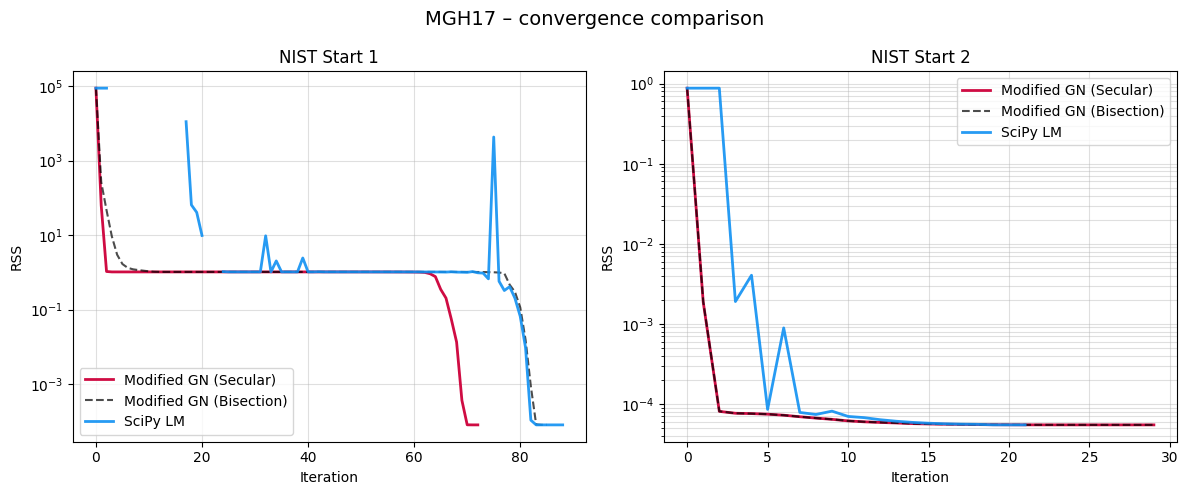


=== Roszman1 ===


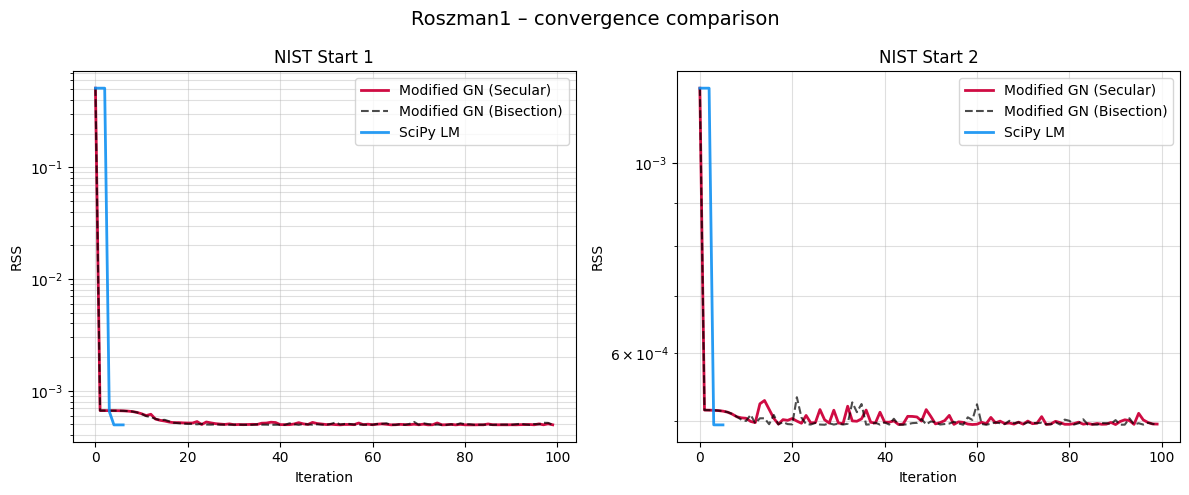


=== Thurber ===


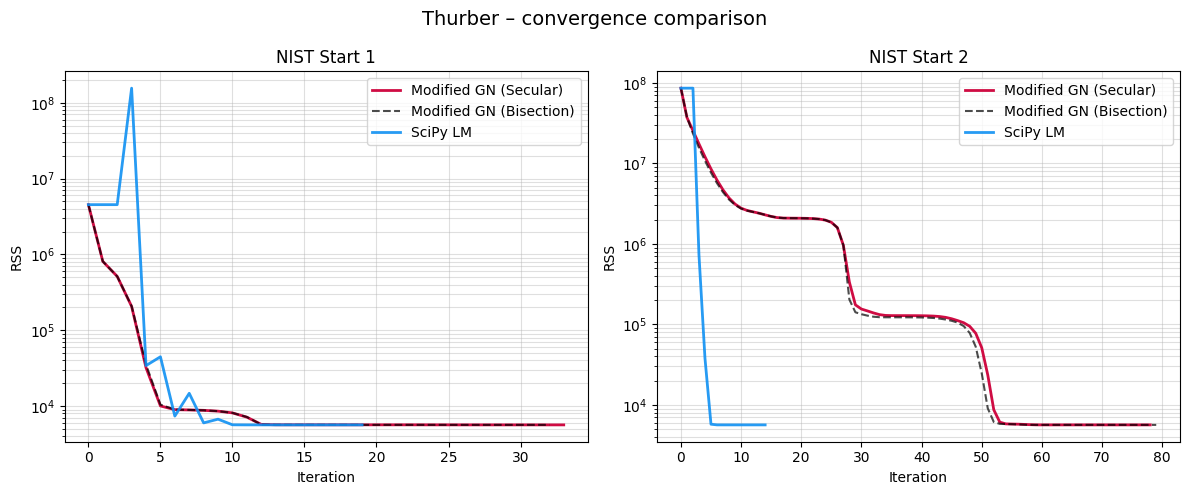

In [16]:
compare_methods_convergence(problems)